## Imports

In [1]:
import json
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

In [2]:
lasso_or_knn = "knn"

## Load scores and plotting metadata

In [4]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/essential_lfc.csv", index_col=0)

In [5]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = {
    k.replace("HEAD_TYPE", lasso_or_knn): v
    for k, v in fig_index["essential_lfc"].items()
}
model_type_palette = fig_index['genes_model_type_palette']
hue_order = fig_index['genes_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])

## Boxplot

K-562:
	train mean: 4.958851881410832
	exp err: 4.570094505703786 
	best: 4.6586095214664125
	viable range: 0.3887573757070468
	improvement: 0.30024235994441995
	fraction achieved: 0.7723129610039128
Hep-G2:
	train mean: 7.088296665452211
	exp err: 6.440344860875873 
	best: 6.682967822074454
	viable range: 0.6479518045763379
	improvement: 0.4053288433777569
	fraction achieved: 0.6255540003361522
Jurkat:
	train mean: 6.528218630411582
	exp err: 6.344629938378517 
	best: 6.298276458761712
	viable range: 0.18358869203306494
	improvement: 0.22994217164987063
	fraction achieved: 1.2524854831933618
hTERT-RPE1:
	train mean: 7.58406504380432
	exp err: 5.944282387754929 
	best: 7.035404402810678
	viable range: 1.639782656049391
	improvement: 0.5486606409936421
	fraction achieved: 0.3345935139450067


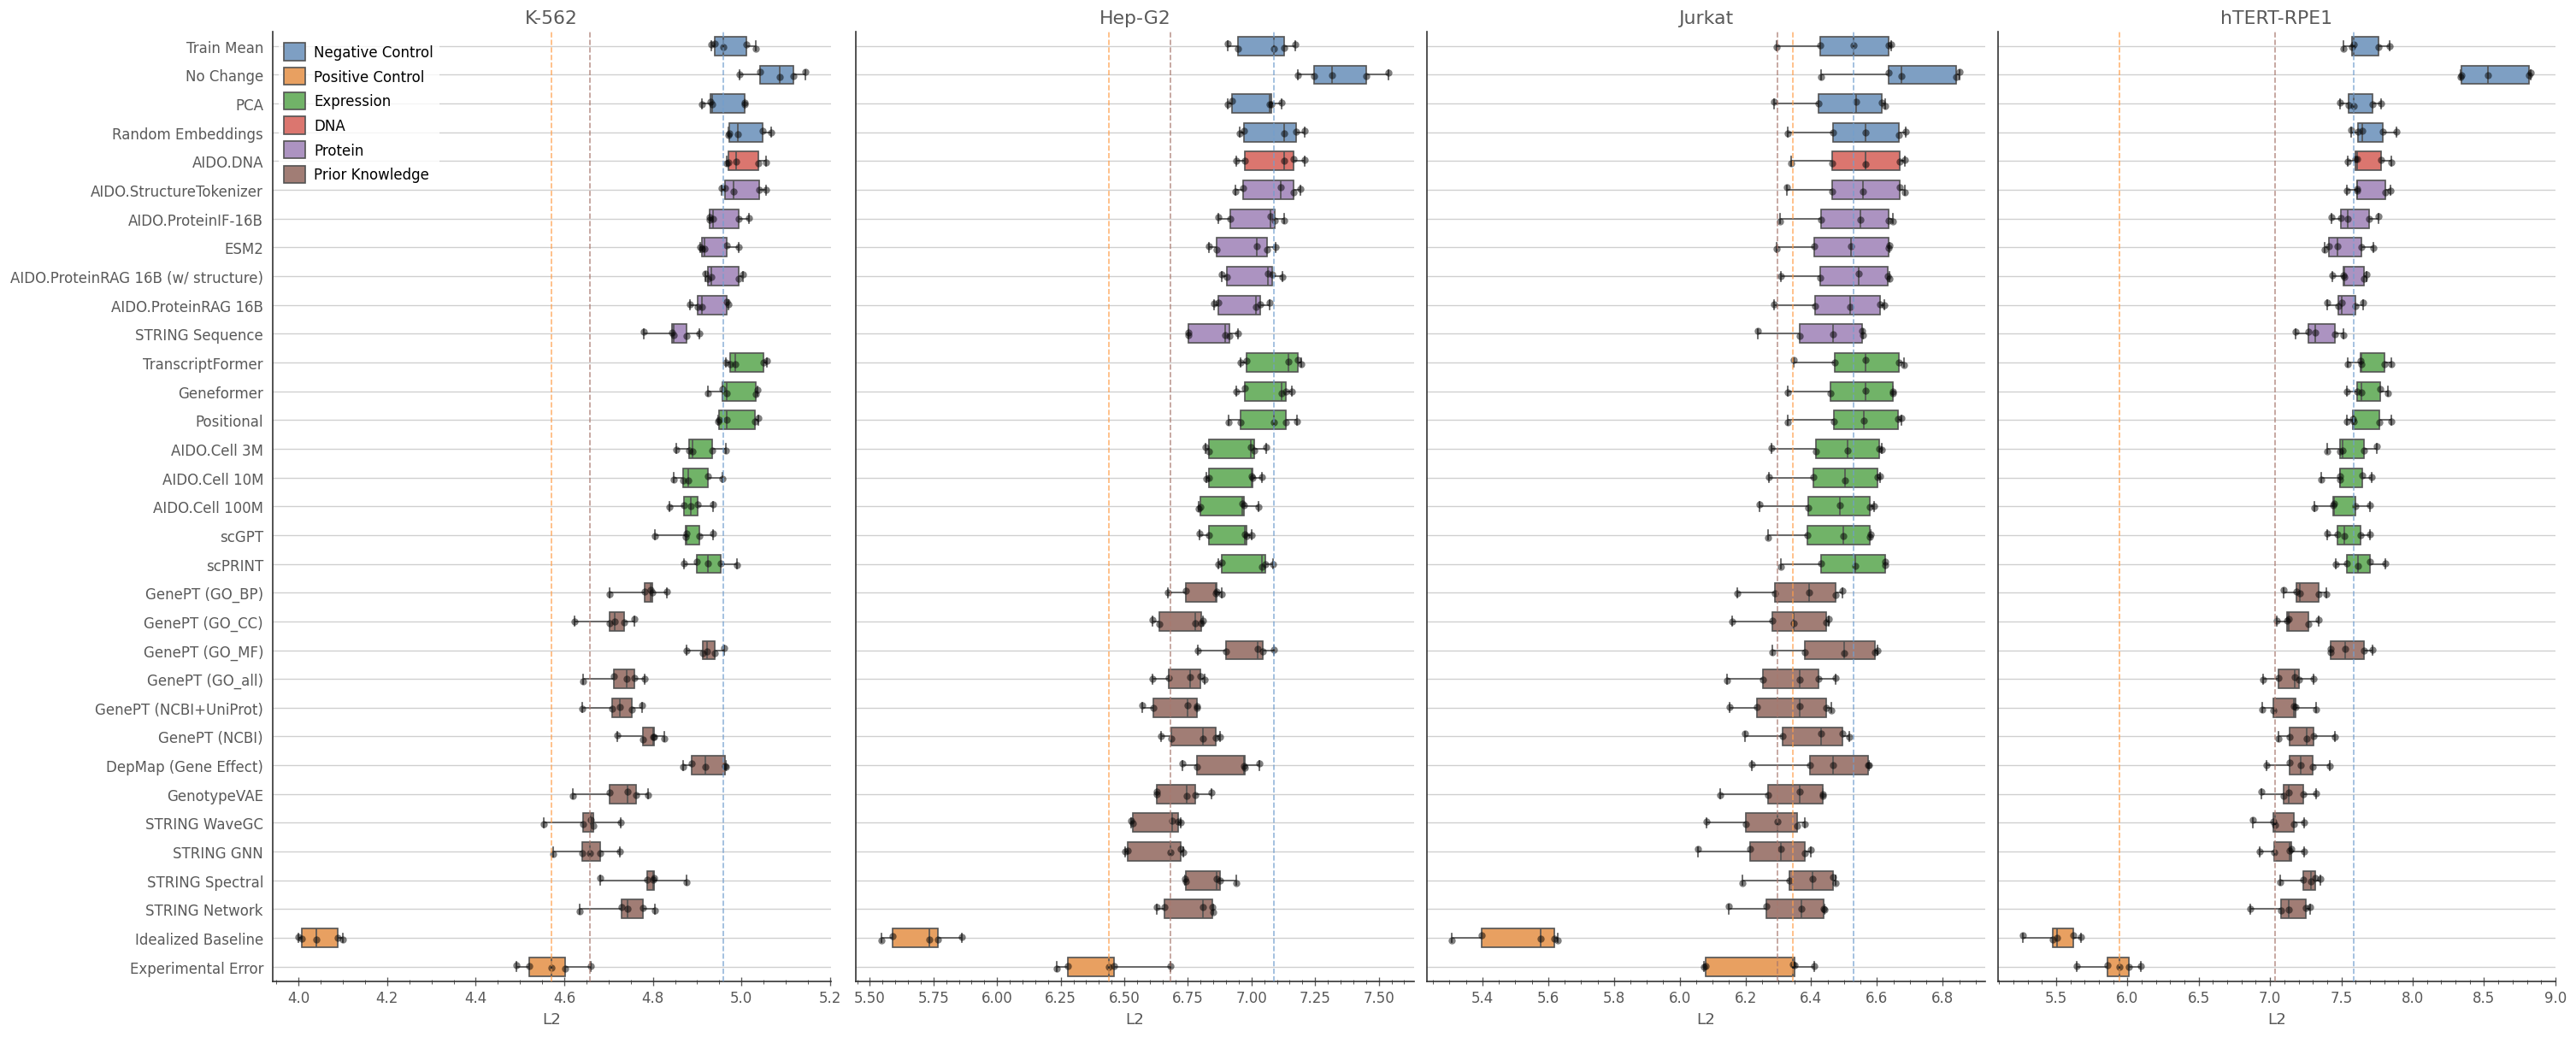

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(25, 10), constrained_layout=True)
for i, cell_line in enumerate(["K-562", "Hep-G2", "Jurkat", "hTERT-RPE1"]):

    # Build the dataframe
    method_list = [e.replace("CELL_LINE", cell_line) for e in method_map]
    idx = df["fold"].str.contains(cell_line) & df["name"].isin(method_list)
    df_subset = df[idx].copy()
    df_subset["name"] = df_subset["name"].str.replace(cell_line, "CELL_LINE")
    df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
    df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

    # Boxplot
    g = sns.boxplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        hue="Model type",
        x="L2",
        ax=axes[i],
        whis=(0, 100),
        width=0.65, 
        palette=model_type_palette
    )

    # Overlay datapoints
    sns.stripplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        color="black",
        alpha=0.5,
        x="L2",
        ax=axes[i],
    )

    # Decorate
    g.grid(axis="y")
    g.set(ylabel=None, title=cell_line)
    g.legend(title=None)
    if i > 0:
        g.set(yticklabels=[])
        g.legend().remove()
    
    # Get the best model
    best_mask = (
        (df_subset["Model type"] != "Positive Control") &
        (df_subset["Model type"] != "Fusion")
    )
    best_group = (
        df_subset.loc[best_mask]
        .groupby("name")["L2"]
        .median()
    )
    best_name = best_group.idxmin()
    best_level = best_group.loc[best_name]
    best_model_type = (
        df_subset.loc[df_subset["name"] == best_name, "Model type"]
        .iloc[0]
    )

    # Draw vertical lines
    train_mean_level = df_subset[df_subset["name"] == "Train Mean"]["L2"].median()
    g.axvline(train_mean_level, color=model_type_palette["Negative Control"], linestyle="--", linewidth=1, zorder=99, alpha=.75)
    exp_err_level = df_subset[df_subset["name"] == f"Experimental Error"]["L2"].median()
    g.axvline(exp_err_level, color=model_type_palette["Positive Control"], linestyle="--", linewidth=1, zorder=99, alpha=.75)
    g.axvline(best_level, color=model_type_palette[best_model_type], linestyle="--", linewidth=1, zorder=99, alpha=.75)

    # Display info
    print(
        f'{cell_line}:\n'
        f'\ttrain mean: {train_mean_level}\n'
        f'\texp err: {exp_err_level} \n'
        f'\tbest: {best_level}\n'
        f'\tviable range: {train_mean_level - exp_err_level}\n'
        f'\timprovement: {train_mean_level - best_level}\n'
        f'\tfraction achieved: {(train_mean_level - best_level)/(train_mean_level - exp_err_level)}'
    )
plt.savefig("fig_1.pdf")